# Prestações de Contas — Análise Aprofundada (mai/2022–ago/2023)

Notebook focado nas prestações de contas do Condomínio Humaitá.

**Fonte**: `exports/csv/prestacoes.csv` — lançamentos mai/2022–ago/2023

> Para análise dos Extratos Bancários (ago/2025–jun/2026) ver `analise_extratos.ipynb`

In [222]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 5)})
sns.set_theme(style="whitegrid", palette="tab10")

CSV_DIR       = Path("../exports/csv")
PRESTACAO_DIR = Path("../exports/hojas/prestacao")


def _br(s) -> float | None:
    """Converte string BR (1.234,56) ou número para float."""
    if isinstance(s, (int, float)):
        return None if pd.isna(s) else float(s)
    s = str(s).strip()
    if s in ("-", "", "nan"):
        return None
    try:
        return float(re.sub(r"\s", "", s).replace(".", "").replace(",", "."))
    except ValueError:
        return None

## 1. Carregar dados

In [223]:
df_prest = pd.read_csv(CSV_DIR / "prestacoes.csv")

print(f"Prestações : {len(df_prest):,} registros  |  {df_prest['mes_ano'].min()} → {df_prest['mes_ano'].max()}")
print(f"\nColunas: {list(df_prest.columns)}")

Prestações : 711 registros  |  2022-05 → 2023-08

Colunas: ['mes_ano', 'tipo', 'evento', 'valor', 'macro_categoria']


## 1.5 Validação — conferência com subtotais originais

Compara as somas do nosso CSV contra a linha "Subtotal" de cada aba Receitas/Despesas dos arquivos `.xlsx` originais.

In [224]:
# ══════════════════════════════════════════════════════════════════════════════
# PRESTAÇÕES — re-lê a linha "Subtotal" do final de cada aba Receitas/Despesas
# e compara com a soma do nosso CSV
# ══════════════════════════════════════════════════════════════════════════════
orig_prest = []
for fp in sorted(PRESTACAO_DIR.glob("*.xlsx")):
    yy, mm = fp.stem.split("_")
    mes_ano = f"{yy}-{mm.zfill(2)}"
    xl = pd.ExcelFile(fp)
    for sheet, tipo in [("Receitas", "receita"), ("Despesas", "despesa")]:
        if sheet not in xl.sheet_names:
            continue
        raw = xl.parse(sheet, header=None).iloc[2:].copy()
        raw.columns = list(range(raw.shape[1]))
        raw = raw[[0, 1]].copy()
        raw.columns = ["evento", "valor"]
        mask = raw["evento"].astype(str).str.lower().str.startswith("subtotal")
        if mask.any():
            orig_prest.append({
                "mes_ano":      mes_ano,
                "tipo":         tipo,
                "subtotal_orig": _br(raw[mask]["valor"].iloc[0]),
            })

df_orig_prest = pd.DataFrame(orig_prest)

# Somas a partir do CSV
df_calc_prest = (
    df_prest.groupby(["mes_ano", "tipo"])["valor"]
    .sum().reset_index()
    .rename(columns={"valor": "soma_csv"})
)

val_prest = df_orig_prest.merge(df_calc_prest, on=["mes_ano", "tipo"], how="left")
val_prest["diff"] = (val_prest["soma_csv"] - val_prest["subtotal_orig"]).round(2)
val_prest["ok"]   = val_prest["diff"].abs() < 0.05

n_ok_p = val_prest["ok"].sum()
n_tot_p = len(val_prest)
print(f"Prestações — {n_ok_p}/{n_tot_p} abas/mês validadas")

falhas_prest = val_prest[~val_prest["ok"]]
if falhas_prest.empty:
    print("✓ Todos os subtotais das prestações conferem com os originais!")
else:
    print(f"\n⚠️  {len(falhas_prest)} discrepância(s) detectada(s):")
    display(val_prest.sort_values("ok").reset_index(drop=True))

Prestações — 30/30 abas/mês validadas
✓ Todos os subtotais das prestações conferem com os originais!


## 2. Normalização de nomes e macro-categorias

Mapeamento do campo `historico` (extratos) / `evento` (prestações) para categorias padronizadas.
Edite o dicionário `CATEGORIA_MAP` conforme necessário — qualquer histórico não mapeado fica como `"Outros"`.

In [225]:
MACRO_MAP: dict[str, list[str]] = {
    "Pessoal": [
        "PG.SALÁRIO", "PG.ADTO.SALÁRIO", "PG.1º PARC.13º SAL.", "PG.2º PARC.13º SAL.",
        "PG.FGTS", "PG.DARF INSS", "PG.FÉRIAS", "PG.FÉRIAS PERÍODO",
        "PG.VALE TRANSPORTE", "PG.VALE REFEIÇÃO", "PG.VALE ALIMENTAÇÃO",
        "PG.SEG.VIDA", "PG.PIS", "PG.SÍNDICO",
        "PG.SALARIO", "PG.ADTO.SALARIO",
        "PG.PIS/COFINS", "PG.EMISSÃO DARF",
        "PG.EFD-REINF", "PG.ELAB-REINF",
        "13º SALARIO", "PG.1º PARC", "PG.2º PARC",
        "INDENIZ.FUNC.", "PG.INDENIZAÇÃO", "PG.INDENIZACAO",
        "PG.SINDEF", "PG.DISSÍDIO", "PG.DISSIDIO",
        "PG.INSS S/13", "PG.CONTR.SIND",
    ],
    "Utilidades": [
        "ÁGUA/ESGOTO", "AGUA/ESGOTO",
        "PG.CEEE", "PG. INTERNET", "PG.INTERNET", "PG.CLARO",
        "PG.SERV.PORTARIA", "PG.SERV.LIMP.", "PG.SERV.LIMP",
        "PG.MAT.LIMPEZA", "PG.TELEFONE",
    ],
    "Manutenção": [
        "PG.MATERIAL", "PG.REPAROS", "PG.REP.HIDRÁULICO", "PG.REP.HIDRAULICO",
        "PG.REP.ELEVADOR", "PG.MANUT.ELEVADOR", "PG.BÓIA", "PG.BOIA",
        "PEÇAS ELEVADOR", "PG.SERV.PRESTADOS",
        "TELHADO", "PG.MAT.PINTURA", "PG.MANUTENÇÃO", "PG.MANUTENCAO",
        "PG.REP.GESSO", "PG.REFORMA", "PG.MANUT.BOMBAS", "PG.REP.ELÉTRICO",
        "PG.REP.ELETRICO", "PG.FECHADURA", "PG.PINTURA", "PG.REP.BOMBAS",
        "PG.CONS.PORTÃO", "PG.CONS.PORTAO", "PG.MANUT.PORTÃO", "PG.MANUT.PORTAO",
        "PG.INSTALAÇÃO", "PG.INSTALACAO", "REP.HIDRÁULICO", "REP.HIDRAULICO",
        "PG.LIMP.CX.D.ÁGUA", "PG. MÓVEIS", "PG.MOVEIS",
        "PG. SENSOR", "PG.SENSOR", "PG.INSTAL.CÂMERAS", "PG.INSTAL.CAMERAS",
        "PG.BALCÃO", "PG.BALCAO",
    ],
    "Taxas e Impostos": [
        "PG.ISSQN", "PG.TX.FIN", "PG.SECOVIMED",
        "PG.DECLARAÇÃO PMPA", "PG.DECLARACAO PMPA",
        "PG.TRANSAÇÕES BCO", "PG.TRANSACOES BCO",
        "PG.PCMSO",
    ],
    "Administração": [
        "TAXA AUXILIAR ADMINISTRACAO", "TAXA AUXILIAR ADMINISTRAÇÃO",
        "REEMB.MAT.EXPEDIENTE",
        "PG.TARIFA BANCO", "PG.FOLHA FUNC.BCO", "PG.IMPRESSÕES",
        "PG.IMPRESSOES", "PG.REMESSA DOCTOS",
        "E-CONSIGNADO CLT", "PG.SEGURO INCÊNDIO", "PG.SEGURO INCENDIO",
        "PG.ACORDO", "PG.DESCARTE DOCUM", "HONOR.ADVOC",
    ],
    "Receitas Condominiais": [
        "REC.CONDOMÍNIO", "REC.CONDOMINIO",
        "REC. MULTA", "REC.MULTA", "REC.MULTA+C.M.+JRS.",
        "REC.COND.ESTACIONAMENTO", "REC.ACORDO", "REC.JUROS",
        "REC.DEVOLUÇÃO", "REC.DEVOLUÇAO",
    ],
    "Fundos": [
        "13º SALARIO", "DIF.SALARIAL",
        "FUNDO OBRAS", "FUNDO FÉRIAS", "FUNDO RESERVA",
        "REC.CH.EXTRA FÉRIAS", "REC.CH.EXTRA FERIAS",
        "REC.ALUG.DEPÓSITO", "REC.ALUG.DEPOSITO",
        "REC.TAXA USO BOX", "OUTROS EVENTOS",
    ],
    "Retiradas/Acerto": [
        "RETIRADA P/POSTERIOR", "PG.RETIRADA", "ESTORNO",
    ],
}

_LOOKUP: list[tuple[str, str]] = []
for macro, keywords in MACRO_MAP.items():
    for kw in keywords:
        _LOOKUP.append((kw.upper(), macro))
_LOOKUP.sort(key=lambda x: len(x[0]), reverse=True)


def get_macro(historico: str) -> str:
    h = str(historico).upper().strip()
    for kw, macro in _LOOKUP:
        if kw in h:
            return macro
    return "Outros"


df_prest["macro_categoria"] = df_prest["evento"].apply(get_macro)

print("=== Prestações — distribuição por macro_categoria ===")
print(df_prest["macro_categoria"].value_counts().to_string())

=== Prestações — distribuição por macro_categoria ===
macro_categoria
Pessoal                  194
Outros                   101
Administração             87
Manutenção                77
Receitas Condominiais     71
Taxas e Impostos          65
Fundos                    54
Utilidades                54
Retiradas/Acerto           8


In [226]:
nao_mapeados = (
    df_prest[df_prest["macro_categoria"] == "Outros"]["evento"]
    .value_counts()
)
if nao_mapeados.empty:
    print("✓ Todos os eventos foram mapeados!")
else:
    print(f"Eventos não mapeados ({len(nao_mapeados)} únicos):")
    print(nao_mapeados.to_string())

Eventos não mapeados (43 únicos):
evento
ÁGUA                           12
PG.MATERIAIS                   12
VALOR                           7
PG.                             5
PG.EQUIPAMENTOS                 5
PG.CORREIO CONV.ASSEMB.C/AR     4
PG.IMPERMEABILIZAÇÃO            4
PG.ESCADA                       4
PG.RECARGA CELULAR              3
PG.ASSEMB.ORDIN.                3
PG.SACOS LIXO                   3
PG.CUSTAS JUDICIAIS             3
PG.VISTORIA HIDRÁULICA          2
PG. IRRF                        2
PG.DESP.CARTÓRIO                2
PG.DESENTUPIDORA                2
PG.RECARGA EXTINTORES           2
PG.ASSEMB.EXTRA                 1
PG.EXTINTORES                   1
PG.ENCERRAMENTO                 1
REC.                            1
DIF.CONDOMÍNIO                  1
DIF.FDO.RESERVA                 1
PG.CONS.FECHADURA               1
PG. ABERTURA PORTA              1
PG.GRATIFICAÇÃO                 1
S/DÉB.                          1
ADTO.13º SALÁRIO                1
PG.REG.

## 3. Anomalias — Prestações de Contas

In [227]:
anomalias_p: list = []

# ── 1. Outliers por categoria (IQR) ───────────────────────────────────────
desp_p = df_prest[df_prest["tipo"] == "despesa"].copy()
for categoria, grupo in desp_p.groupby("macro_categoria"):
    q1, q3 = grupo["valor"].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite = q3 + 1.5 * iqr
    outliers = grupo[grupo["valor"] > limite].copy()
    outliers["motivo_anomalia"] = f"Outlier IQR ({categoria}): > R$ {limite:,.2f}"
    anomalias_p.append(outliers)

# ── 2. Eventos não mapeados ────────────────────────────────────────────────
nao_cat = df_prest[df_prest["macro_categoria"] == "Outros"].copy()
nao_cat["motivo_anomalia"] = "Evento sem categoria mapeada"
anomalias_p.append(nao_cat)

# ── Consolidar ──────────────────────────────────────────────────────────────
df_anomalias = (
    pd.concat([a for a in anomalias_p if not a.empty], ignore_index=True)
    .drop_duplicates(subset=["mes_ano", "evento", "tipo", "valor"])
)

print(f"Total de anomalias nas prestações: {len(df_anomalias)}")
print(df_anomalias["motivo_anomalia"].value_counts().to_string())

Total de anomalias nas prestações: 113
motivo_anomalia
Evento sem categoria mapeada                     86
Outlier IQR (Outros): > R$ 8,000.14              15
Outlier IQR (Manutenção): > R$ 4,630.55           9
Outlier IQR (Taxas e Impostos): > R$ 1,127.58     2
Outlier IQR (Pessoal): > R$ 3,660.43              1


In [228]:
df_anomalias[["mes_ano", "evento", "tipo", "valor", "macro_categoria", "motivo_anomalia"]].sort_values(["motivo_anomalia", "mes_ano"]).head(30)

,mes_ano,evento,tipo,valor,macro_categoria,motivo_anomalia
27,2022-05,PG.ASSEMB.EXTRA,despesa,204.70,Outros,Evento sem categoria mapeada
28,2022-05,ÁGUA,despesa,6809.78,Outros,Evento sem categoria mapeada
29,2022-05,PG.EXTINTORES,despesa,30.00,Outros,Evento sem categoria mapeada
30,2022-05,PG.,despesa,55.26,Outros,Evento sem categoria mapeada
31,2022-05,PG.MATERIAIS,despesa,2284.43,Outros,Evento sem categoria mapeada
33,2022-06,REC.,receita,124.49,Outros,Evento sem categoria mapeada
34,2022-06,DIF.CONDOMÍNIO,despesa,529.92,Outros,Evento sem categoria mapeada
35,2022-06,ÁGUA,despesa,6883.40,Outros,Evento sem categoria mapeada
36,2022-06,PG.RECARGA CELULAR,despesa,95.00,Outros,Evento sem categoria mapeada
37,2022-06,PG.CORREIO CONV.ASSEMB.C/AR,despesa,441.45,Outros,Evento sem categoria mapeada


## 4. Visualizações

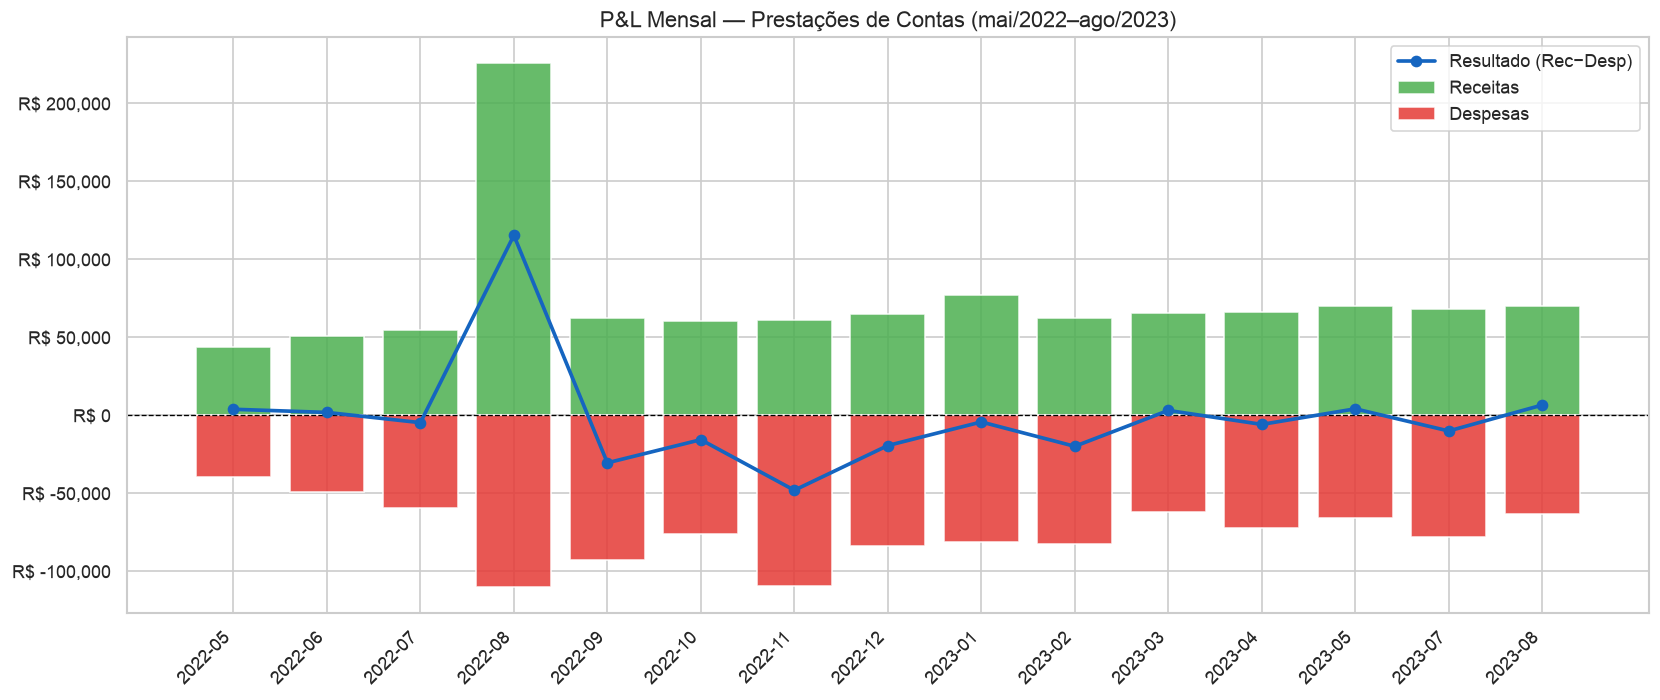

In [229]:
# ── 4.1 P&L Mensal — Receitas vs Despesas + Resultado ─────────────────────
pl = (
    df_prest.groupby(["mes_ano", "tipo"])["valor"]
    .sum()
    .unstack(fill_value=0)
)
pl["resultado"] = pl.get("receita", 0) - pl.get("despesa", 0)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(pl))
ax.bar(x, pl.get("receita", 0),  label="Receitas",  color="#4caf50", alpha=0.85)
ax.bar(x, -pl.get("despesa", 0), label="Despesas",  color="#e53935", alpha=0.85)
ax.plot(x, pl["resultado"], color="#1565c0", marker="o", linewidth=2.2,
        label="Resultado (Rec−Desp)", zorder=5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(pl.index, rotation=45, ha="right")
ax.set_title("P&L Mensal — Prestações de Contas (mai/2022–ago/2023)", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

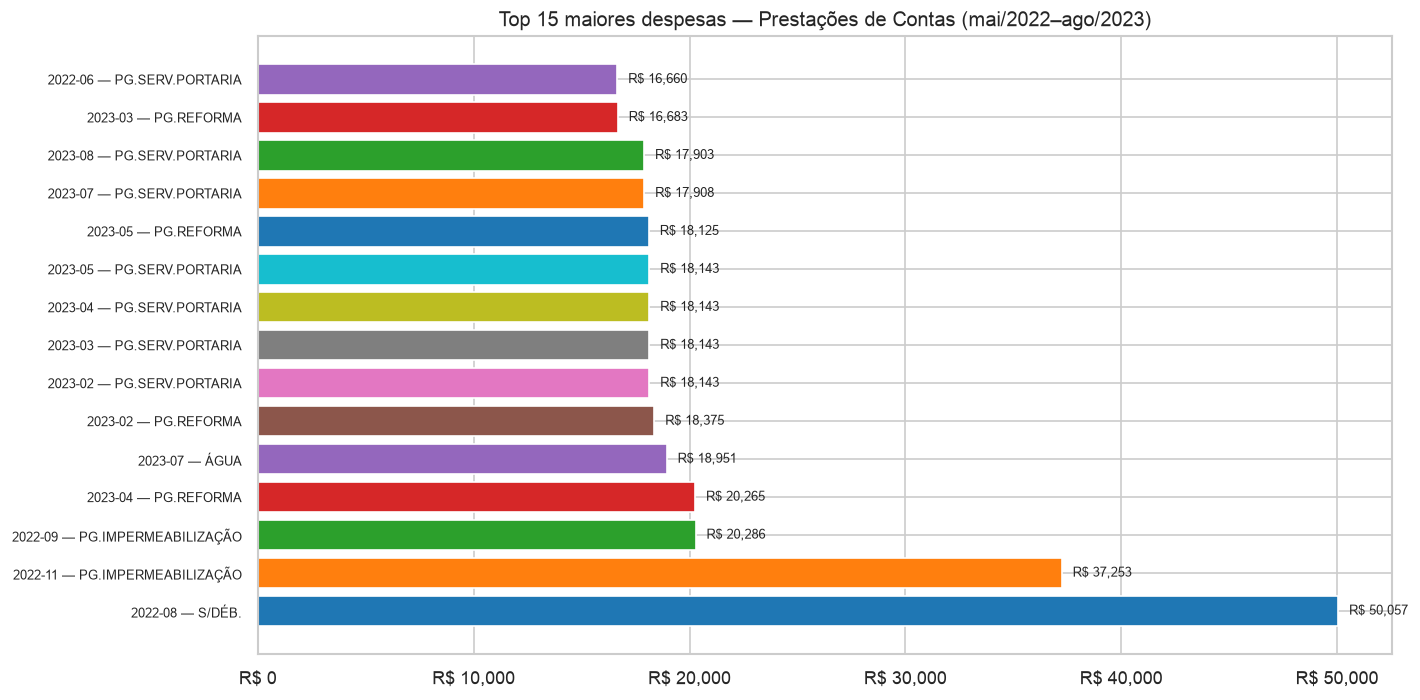

In [230]:
# ── 4.2 Top 15 maiores despesas individuais do período ─────────────────────
top_desp = (
    df_prest[df_prest["tipo"] == "despesa"]
    .nlargest(15, "valor")[["mes_ano", "evento", "valor", "macro_categoria"]]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    range(len(top_desp)),
    top_desp["valor"],
    color=sns.color_palette("tab10", len(top_desp)),
)
ax.set_yticks(range(len(top_desp)))
ax.set_yticklabels(
    [f"{r.mes_ano} — {r.evento[:40]}" for r in top_desp.itertuples()], fontsize=8
)
for bar, val in zip(bars, top_desp["valor"]):
    ax.text(bar.get_width() + top_desp["valor"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"R$ {val:,.0f}", va="center", fontsize=8)
ax.set_title("Top 15 maiores despesas — Prestações de Contas (mai/2022–ago/2023)", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
plt.tight_layout()
plt.show()

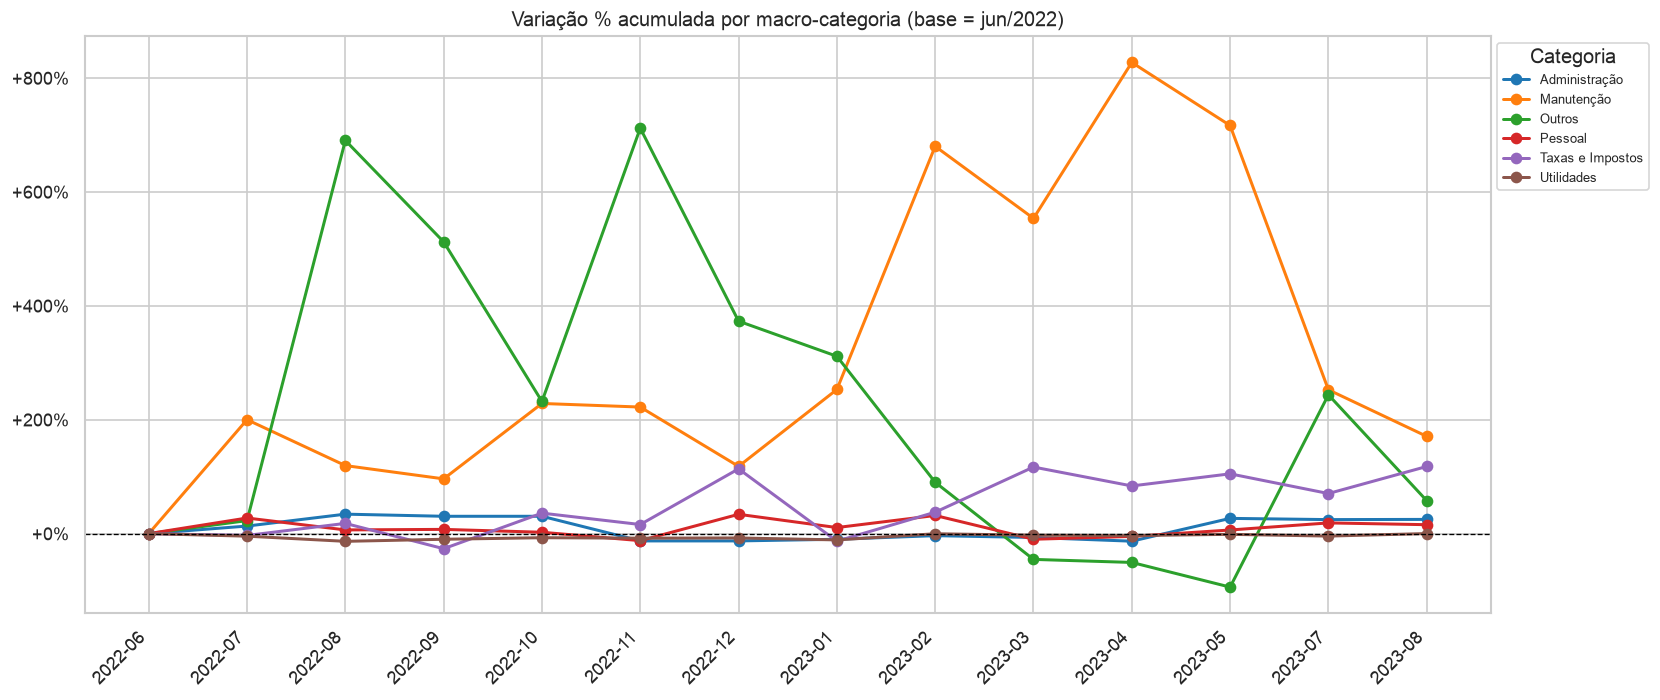

In [231]:
# ── 4.3 Variação % acumulada por macro-categoria (base = jun/2022) ─────────
# mai/2022 excluído: mês atípico — portaria e limpeza ainda não iniciados
# Categorias com base < R$ 500 em jun/2022 excluídas (base instável → spikes)
desp_cat = (
    df_prest[df_prest["tipo"] == "despesa"]
    .groupby(["mes_ano", "macro_categoria"])["valor"]
    .sum()
    .unstack(fill_value=0)
)
desp_cat = desp_cat.loc[desp_cat.index >= "2022-06"]
base = desp_cat.iloc[0]

cats_validas = base[base >= 500].index
desp_cat     = desp_cat[cats_validas]
base         = base[cats_validas].replace(0, float("nan"))
variacao_pct = ((desp_cat - base) / base) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for col in variacao_pct.columns:
    ax.plot(variacao_pct.index, variacao_pct[col], marker="o", linewidth=1.8, label=col)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Variação % acumulada por macro-categoria (base = jun/2022)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8, title="Categoria")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

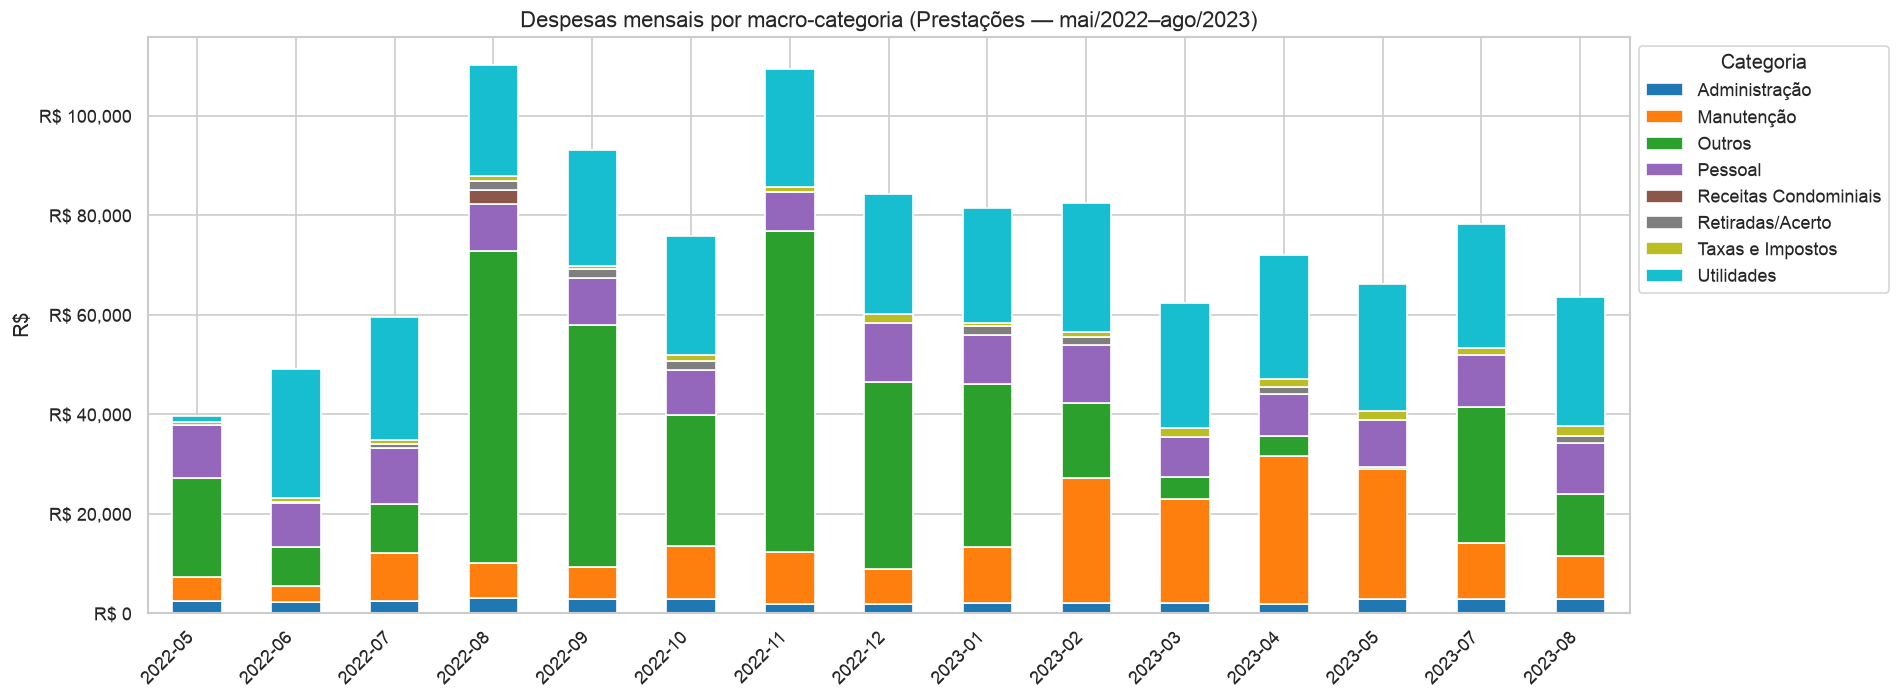

In [232]:
# ── 4.4 Prestações — evolução mensal de despesas por macro-categoria ───────
desp_prest = (
    df_prest[df_prest["tipo"] == "despesa"]
    .groupby(["mes_ano", "macro_categoria"])["valor"]
    .sum()
    .reset_index()
)

pivot_prest = desp_prest.pivot(index="mes_ano", columns="macro_categoria", values="valor").fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))
pivot_prest.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Despesas mensais por macro-categoria (Prestações — mai/2022–ago/2023)", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("R$")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Categoria")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Síndico — Evolução nos Dados de Prestações (2022–2023)

Análise dos pagamentos ao síndico profissional no período mai/2022–ago/2023.
Para a visão completa 2022–2026 com saques e reconciliação, ver `analise_extratos.ipynb`.

In [233]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.1 Pagamentos ao síndico nas prestações (2022–2023)
# ═══════════════════════════════════════════════════════════════════════════
sind_prest = df_prest[
    df_prest["evento"].str.upper().str.contains(r"SÍNDICO|SINDICO", na=False)
].copy()

sind_prest_m = sind_prest.groupby("mes_ano")["valor"].sum().reset_index()

print("=== Pagamentos ao síndico (2022-2023) ===")
print(sind_prest[["mes_ano", "evento", "valor"]].to_string(index=False))
print(f"\nMédia mensal : R$ {sind_prest['valor'].mean():,.2f}")
print(f"Mínimo       : R$ {sind_prest['valor'].min():,.2f}")
print(f"Máximo       : R$ {sind_prest['valor'].max():,.2f}")
variacao = (sind_prest["valor"].iloc[-1] / sind_prest["valor"].iloc[0] - 1) * 100
print(f"Variação no período: {variacao:+.1f}%")

=== Pagamentos ao síndico (2022-2023) ===
mes_ano           evento  valor
2022-05 PG.SÍNDICO PROF. 1750.0
2022-06 PG.SÍNDICO PROF. 1750.0
2022-07 PG.SÍNDICO PROF. 1750.0
2022-08 PG.SÍNDICO PROF. 3500.0
2022-09 PG.SÍNDICO PROF. 1750.0
2022-10 PG.SÍNDICO PROF. 1750.0
2022-12 PG.SÍNDICO PROF. 1750.0
2023-01 PG.SÍNDICO PROF. 3500.0
2023-02 PG.SÍNDICO PROF. 3600.0
2023-04 PG.SÍNDICO PROF. 1850.0
2023-05 PG.SÍNDICO PROF. 1850.0
2023-07 PG.SÍNDICO PROF. 1850.0
2023-08 PG.SÍNDICO PROF. 1850.0

Média mensal : R$ 2,192.31
Mínimo       : R$ 1,750.00
Máximo       : R$ 3,600.00
Variação no período: +5.7%


/var/folders/6n/lp0kv32n54dgmr9xgyd1yg7m0000gn/T/ipykernel_50309/2754346808.py:32: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chris/Documents/analisis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


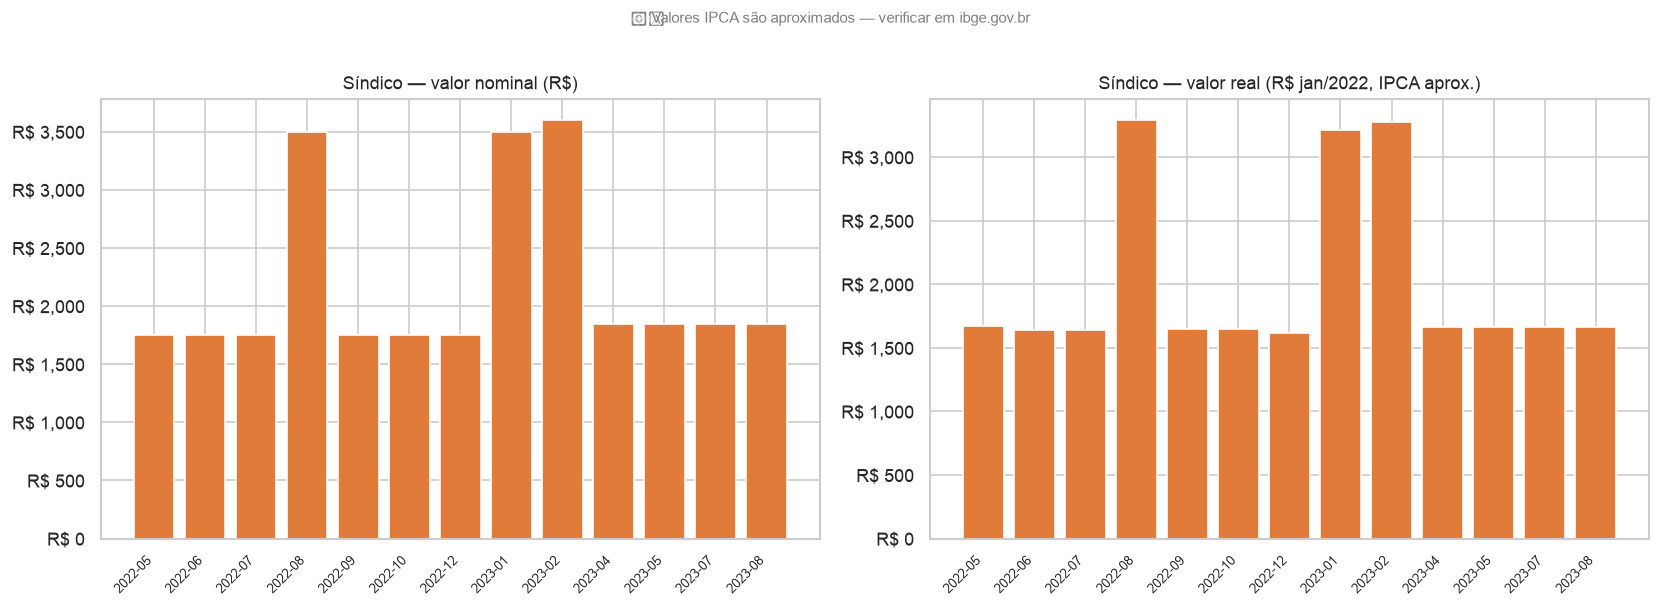

mes_ano  valor   ipca  valor_real
2022-05 1750.0 1.0473     1670.96
2022-06 1750.0 1.0671     1639.96
2022-07 1750.0 1.0671     1639.96
2022-08 3500.0 1.0633     3291.64
2022-09 1750.0 1.0590     1652.50
2022-10 1750.0 1.0627     1646.75
2022-12 1750.0 1.0809     1619.02
2023-01 3500.0 1.0893     3213.07
2023-02 3600.0 1.0987     3276.60
2023-04 1850.0 1.1112     1664.87
2023-05 1850.0 1.1107     1665.62
2023-07 1850.0 1.1096     1667.27
2023-08 1850.0 1.1127     1662.62


In [234]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.2 Evolução nominal vs real (IPCA aprox., base jan/2022)
# ═══════════════════════════════════════════════════════════════════════════
IPCA_BASE_JAN22 = {
    "2022-05": 1.0473, "2022-06": 1.0671, "2022-07": 1.0671,
    "2022-08": 1.0633, "2022-09": 1.0590, "2022-10": 1.0627,
    "2022-11": 1.0692, "2022-12": 1.0809,
    "2023-01": 1.0893, "2023-02": 1.0987, "2023-03": 1.1071,
    "2023-04": 1.1112, "2023-05": 1.1107, "2023-07": 1.1096,
    "2023-08": 1.1127,
}

sind_prest_m["ipca"] = sind_prest_m["mes_ano"].map(IPCA_BASE_JAN22)
sind_prest_m["valor_real"] = (sind_prest_m["valor"] / sind_prest_m["ipca"]).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(sind_prest_m))

axes[0].bar(x, sind_prest_m["valor"], color="#e07b39")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sind_prest_m["mes_ano"], rotation=45, ha="right", fontsize=8)
axes[0].set_title("Síndico — valor nominal (R$)", fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

axes[1].bar(x, sind_prest_m["valor_real"], color="#e07b39")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sind_prest_m["mes_ano"], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Síndico — valor real (R$ jan/2022, IPCA aprox.)", fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

plt.suptitle("⚠️ Valores IPCA são aproximados — verificar em ibge.gov.br", fontsize=9, color="gray", y=1.01)
plt.tight_layout()
plt.show()

print(sind_prest_m.to_string(index=False))

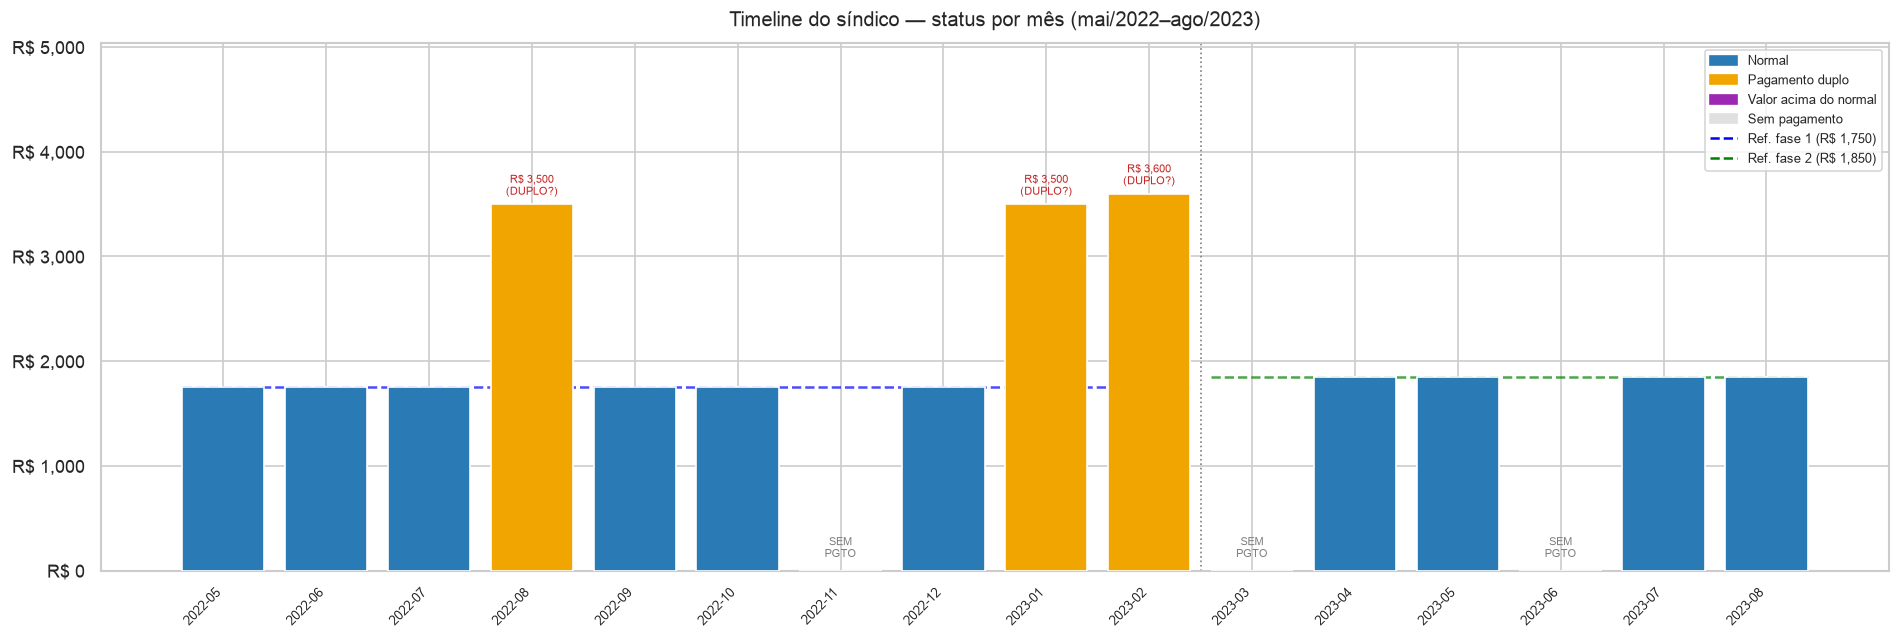

mes_ano  valor          status
2022-05 1750.0          Normal
2022-06 1750.0          Normal
2022-07 1750.0          Normal
2022-08 3500.0 Pagamento duplo
2022-09 1750.0          Normal
2022-10 1750.0          Normal
2022-11    0.0   Sem pagamento
2022-12 1750.0          Normal
2023-01 3500.0 Pagamento duplo
2023-02 3600.0 Pagamento duplo
2023-03    0.0   Sem pagamento
2023-04 1850.0          Normal
2023-05 1850.0          Normal
2023-06    0.0   Sem pagamento
2023-07 1850.0          Normal
2023-08 1850.0          Normal


In [235]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.3 Timeline do síndico — status por mês (normal / duplo / reajuste / ausente)
# ═══════════════════════════════════════════════════════════════════════════
from matplotlib.patches import Patch as MPatch

# Período completo mai/2022–ago/2023
todos_meses = (
    pd.period_range(start="2022-05", end="2023-08", freq="M")
    .strftime("%Y-%m").tolist()
)
sind_dict = dict(zip(sind_prest_m["mes_ano"], sind_prest_m["valor"]))


def ref_fase(vals, threshold=1.6):
    """Mediana dos valores 'simples' (excluindo prováveis duplos)."""
    s = pd.Series(vals)
    if s.empty:
        return 0.0
    med = s.median()
    simples = s[s < med * threshold]
    return float(simples.median()) if not simples.empty else float(med)


vals_f1 = [sind_dict[m] for m in todos_meses if m < "2023-03" and m in sind_dict]
vals_f2 = [sind_dict[m] for m in todos_meses if m >= "2023-03" and m in sind_dict]
REF1 = ref_fase(vals_f1)   # ~1 750
REF2 = ref_fase(vals_f2)   # ~1 850


def classificar_mes(mes, valor):
    ref = REF2 if mes >= "2023-03" else REF1
    if valor == 0:
        return "Sem pagamento"
    if valor >= ref * 1.75:
        return "Pagamento duplo"
    if valor > ref * 1.04:
        return "Valor acima do normal"
    return "Normal"


COR = {
    "Normal":               "#2a7ab5",
    "Pagamento duplo":      "#f0a500",
    "Valor acima do normal": "#9c27b0",
    "Sem pagamento":        "#e0e0e0",
}

tl = pd.DataFrame([
    {"mes_ano": m, "valor": sind_dict.get(m, 0),
     "status": classificar_mes(m, sind_dict.get(m, 0))}
    for m in todos_meses
])

fase1_idx = tl.index[tl["mes_ano"] < "2023-03"].tolist()
fase2_idx = tl.index[tl["mes_ano"] >= "2023-03"].tolist()

fig, ax = plt.subplots(figsize=(16, 5.5))

for i, row in tl.iterrows():
    ax.bar(i, row["valor"] or 0, color=COR[row["status"]], zorder=3)
    if row["status"] == "Pagamento duplo":
        ax.text(i, row["valor"] + 60, f"R$ {row['valor']:,.0f}\n(DUPLO?)",
                ha="center", fontsize=6.5, color="#c62828", va="bottom")
    elif row["status"] == "Sem pagamento":
        ax.text(i, 100, "SEM\nPGTO", ha="center", fontsize=6.5, color="gray", va="bottom")
    elif row["status"] == "Valor acima do normal":
        ax.text(i, row["valor"] + 60, f"R$ {row['valor']:,.0f}",
                ha="center", fontsize=6.5, color="#7b1fa2", va="bottom")

if fase1_idx:
    ax.hlines(REF1, min(fase1_idx) - 0.4, max(fase1_idx) + 0.4,
              colors="blue", linestyles="--", linewidth=1.5, alpha=0.7)
if fase2_idx:
    ax.hlines(REF2, min(fase2_idx) - 0.4, max(fase2_idx) + 0.4,
              colors="green", linestyles="--", linewidth=1.5, alpha=0.7)
if fase1_idx and fase2_idx:
    ax.axvline(max(fase1_idx) + 0.5, color="gray", linestyle=":", linewidth=1)

ax.set_xticks(range(len(tl)))
ax.set_xticklabels(tl["mes_ano"], rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax.set_title("Timeline do síndico — status por mês (mai/2022–ago/2023)", fontsize=12, pad=10)
ax.set_ylim(0, tl["valor"].max() * 1.40)
ax.legend(handles=[
    MPatch(color=c, label=l) for l, c in COR.items()
] + [
    plt.Line2D([0], [0], color="blue",  linestyle="--", label=f"Ref. fase 1 (R$ {REF1:,.0f})"),
    plt.Line2D([0], [0], color="green", linestyle="--", label=f"Ref. fase 2 (R$ {REF2:,.0f})"),
], fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

print(tl[["mes_ano", "valor", "status"]].to_string(index=False))

In [236]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.4 Hipótese: os pagamentos duplos cobrem os meses ausentes?
# ═══════════════════════════════════════════════════════════════════════════
meses_ausentes  = tl[tl["status"] == "Sem pagamento"]["mes_ano"].tolist()
meses_duplos    = tl[tl["status"] == "Pagamento duplo"]["mes_ano"].tolist()
meses_acima_ref = tl[tl["status"] == "Valor acima do normal"]["mes_ano"].tolist()

print(f"Meses sem pagamento registrado  : {meses_ausentes}")
print(f"Meses com pagamento duplo       : {meses_duplos}")
print(f"Meses com valor acima do normal : {meses_acima_ref}")
print()

# Para cada mês com valor anômalo, verificar se há mês ausente próximo
print("=== Hipótese: duplo/acima cobrem ausências ===")
for m_ano in meses_duplos + meses_acima_ref:
    v = sind_dict[m_ano]
    ref = REF2 if m_ano >= "2023-03" else REF1
    ausentes_prox = [
        ma for ma in meses_ausentes
        if abs(int(m_ano.replace("-", "")) - int(ma.replace("-", ""))) <= 101
        # tolerância de ~1 mês de calendário
    ]
    # Cálculo direto de distância em meses
    p_ano = pd.Period(m_ano, freq="M")
    ausentes_prox = [
        ma for ma in meses_ausentes
        if abs((pd.Period(ma, freq="M") - p_ano).n) <= 3
    ]
    cobertura = ", ".join(ausentes_prox) if ausentes_prox else "nenhum ausente próximo"
    print(f"  {m_ano}: R$ {v:,.0f}  ≈  {v/ref:.1f}× ref  →  cobertura provável: {cobertura}")

print()
# Custo total real vs. esperado
n_meses = len(todos_meses)
esperado = (
    sum(REF1 for m in todos_meses if m < "2023-03") +
    sum(REF2 for m in todos_meses if m >= "2023-03")
)
total_pago = sum(sind_dict.values())

print(f"Período coberto         : {todos_meses[0]} → {todos_meses[-1]}  ({n_meses} meses)")
print(f"Pagamentos registrados  : {len(sind_dict)}")
print(f"Total pago              : R$ {total_pago:,.2f}")
print(f"Total esperado (mensal) : R$ {esperado:,.2f}")
diff = total_pago - esperado
print(f"Diferença               : R$ {diff:+,.2f}  ({'PAGO A MAIS' if diff > 0 else 'PAGO A MENOS' if diff < 0 else 'igual'})")

Meses sem pagamento registrado  : ['2022-11', '2023-03', '2023-06']
Meses com pagamento duplo       : ['2022-08', '2023-01', '2023-02']
Meses com valor acima do normal : []

=== Hipótese: duplo/acima cobrem ausências ===
  2022-08: R$ 3,500  ≈  2.0× ref  →  cobertura provável: 2022-11
  2023-01: R$ 3,500  ≈  2.0× ref  →  cobertura provável: 2022-11, 2023-03
  2023-02: R$ 3,600  ≈  2.1× ref  →  cobertura provável: 2022-11, 2023-03

Período coberto         : 2022-05 → 2023-08  (16 meses)
Pagamentos registrados  : 13
Total pago              : R$ 28,500.00
Total esperado (mensal) : R$ 28,600.00
Diferença               : R$ -100.00  (PAGO A MENOS)


In [237]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.5 Saques e devoluções do ciclo "p/posterior acerto" nas prestações
# ═══════════════════════════════════════════════════════════════════════════
saques_raw = df_prest[
    df_prest["evento"].str.upper().str.contains("RETIRADA P/POSTERIOR", na=False)
    & (df_prest["tipo"] == "despesa")
].reset_index(drop=True)

devol_raw = df_prest[
    df_prest["evento"].str.upper().str.contains(r"DEVOL.*RETIR", regex=True, na=False)
    & (df_prest["tipo"] == "receita")
].copy()

print("=== Saques registrados (RETIRADA P/POSTERIOR ACERTO) ===")
print(saques_raw[["mes_ano", "evento", "valor"]].to_string(index=False))
print(f"\nTotal sacado: R$ {saques_raw['valor'].sum():,.2f}")

print("\n=== Devoluções registradas ===")
print(devol_raw[["mes_ano", "evento", "valor"]].to_string(index=False))
print(f"Total devolvido: R$ {devol_raw['valor'].sum():,.2f}")

# Match saque → devolução mais próxima
devol_match = devol_raw.copy()
devol_match["_usado"] = False

print("\n=== Correspondência saque → devolução ===")
for _, s in saques_raw.iterrows():
    cand = devol_match[
        (~devol_match["_usado"]) & (devol_match["mes_ano"] >= s["mes_ano"])
    ]
    if not cand.empty:
        idx = cand.index[0]
        devol_match.loc[idx, "_usado"] = True
        d = devol_match.loc[idx]
        prazo = "mesmo mês" if d["mes_ano"] == s["mes_ano"] else f"em {d['mes_ano']}"
        delta = d["valor"] - s["valor"]
        nota  = f"  ← Δ R$ {delta:+,.2f}" if abs(delta) > 1 else ""
        print(f"  {s['mes_ano']}  R$ {s['valor']:,.2f}  →  ✓ devolvido {prazo}  (R$ {d['valor']:,.2f}){nota}")
    else:
        print(f"  {s['mes_ano']}  R$ {s['valor']:,.2f}  →  ⚠️  sem devolução registrada")

saldo_p = saques_raw["valor"].sum() - devol_raw["valor"].sum()
print(f"\nSaldo não devolvido no período: R$ {saldo_p:,.2f}  "
      f"{'✓ tudo devolvido' if abs(saldo_p) < 1 else '⚠️ diferença detectada'}")

=== Saques registrados (RETIRADA P/POSTERIOR ACERTO) ===
mes_ano                      evento  valor
2022-07 RETIRADA P/POSTERIOR ACERTO  800.0
2022-08 RETIRADA P/POSTERIOR ACERTO 1750.0
2022-09 RETIRADA P/POSTERIOR ACERTO 1750.0
2022-10 RETIRADA P/POSTERIOR ACERTO 1800.0
2023-01 RETIRADA P/POSTERIOR ACERTO 1800.0
2023-02 RETIRADA P/POSTERIOR ACERTO 1500.0
2023-04 RETIRADA P/POSTERIOR ACERTO 1500.0
2023-08 RETIRADA P/POSTERIOR ACERTO 1400.0

Total sacado: R$ 12,300.00

=== Devoluções registradas ===
mes_ano                 evento  valor
2022-07 REC.DEVOLUÇÃO RETIRADA  800.0
2022-08 REC.DEVOLUÇÃO RETIRADA 1750.0
2022-09 REC.DEVOLUÇÃO RETIRADA 1750.0
2023-01 REC.DEVOLUÇÃO RETIRADA 1800.0
2023-04 REC.DEVOLUÇÃO RETIRADA 1500.0
2023-07 REC.DEVOLUÇÃO RETIRADA 3300.0
2023-08 REC.DEVOLUÇÃO RETIRADA 1400.0
Total devolvido: R$ 12,300.00

=== Correspondência saque → devolução ===
  2022-07  R$ 800.00  →  ✓ devolvido mesmo mês  (R$ 800.00)
  2022-08  R$ 1,750.00  →  ✓ devolvido mesmo mês  (R$ 1,750

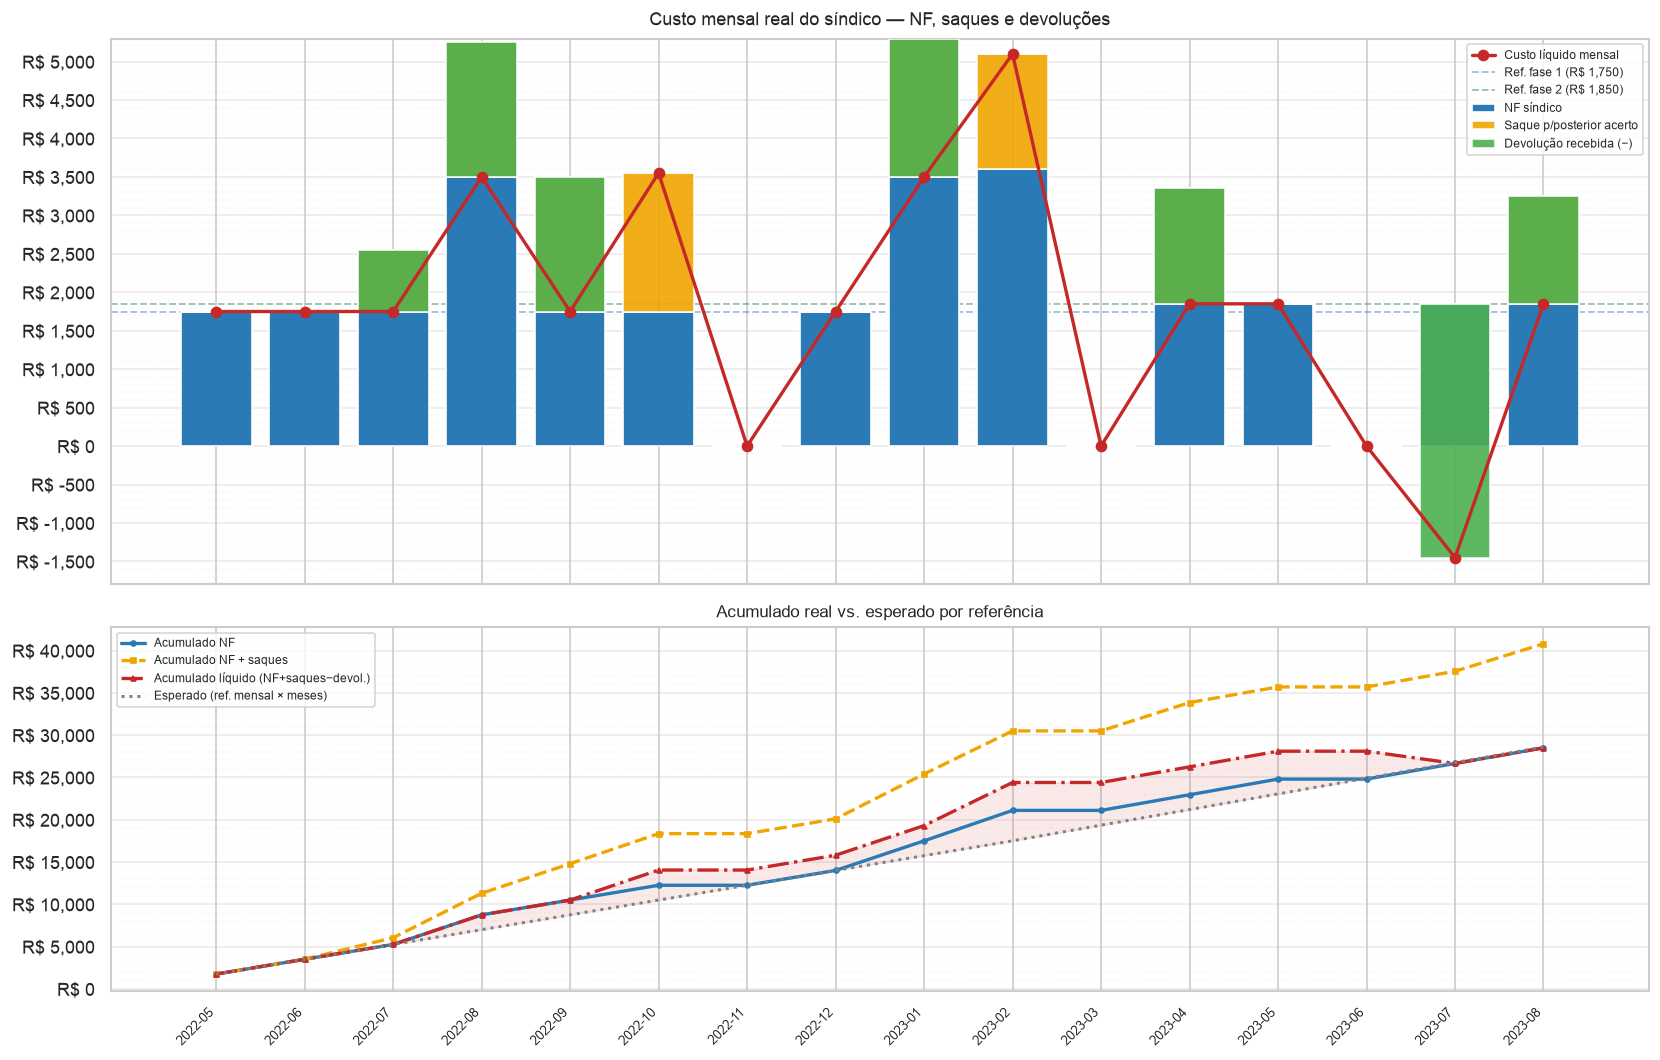

mes_ano     nf  saque  devol  custo_liq  esperado   delta
2022-05 1750.0    0.0    0.0     1750.0    1750.0     0.0
2022-06 1750.0    0.0    0.0     1750.0    1750.0     0.0
2022-07 1750.0  800.0  800.0     1750.0    1750.0     0.0
2022-08 3500.0 1750.0 1750.0     3500.0    1750.0  1750.0
2022-09 1750.0 1750.0 1750.0     1750.0    1750.0     0.0
2022-10 1750.0 1800.0    0.0     3550.0    1750.0  1800.0
2022-12 1750.0    0.0    0.0     1750.0    1750.0     0.0
2023-01 3500.0 1800.0 1800.0     3500.0    1750.0  1750.0
2023-02 3600.0 1500.0    0.0     5100.0    1750.0  3350.0
2023-04 1850.0 1500.0 1500.0     1850.0    1850.0     0.0
2023-05 1850.0    0.0    0.0     1850.0    1850.0     0.0
2023-07 1850.0    0.0 3300.0    -1450.0    1850.0 -3300.0
2023-08 1850.0 1400.0 1400.0     1850.0    1850.0     0.0

Média custo líquido (meses com pgt): R$ 2,192.31
Acumulado líquido final             : R$ 28,500.00
Acumulado esperado final            : R$ 28,600.00
Diferença acumulada (pago − esperado

In [238]:
# ─── 5.5b Custo mensal real + acumulado do síndico ────────────────────────
saques_p = (
    df_prest[
        df_prest["evento"].str.upper().str.contains("RETIRADA P/POSTERIOR", na=False)
        & (df_prest["tipo"] == "despesa")
    ]
    .groupby("mes_ano")["valor"].sum()
    .reindex(todos_meses).fillna(0)
)
devol_p = (
    df_prest[
        df_prest["evento"].str.upper().str.contains(r"DEVOL.*RETIR|DEVOLUÇÃO RETIR", na=False, regex=True)
        & (df_prest["tipo"] == "receita")
    ]
    .groupby("mes_ano")["valor"].sum()
    .reindex(todos_meses).fillna(0)
)

nf_m       = pd.Series([float(sind_dict.get(m, 0)) for m in todos_meses], index=todos_meses)
custo_m    = nf_m + saques_p - devol_p
esperado_m = pd.Series(
    [REF1 if m < "2023-03" else REF2 for m in todos_meses],
    index=todos_meses,
)

cum_nf       = nf_m.cumsum()
cum_nf_saq   = (nf_m + saques_p).cumsum()
cum_net      = custo_m.cumsum()
cum_esperado = esperado_m.cumsum()

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]},
)
x = range(len(todos_meses))

# ── Painel superior: custo mensal ─────────────────────────────────────────
ax1.bar(x, nf_m,     color="#2a7ab5", label="NF síndico",             zorder=3)
ax1.bar(x, saques_p, bottom=nf_m,    color="#f0a500", alpha=0.9,
        label="Saque p/posterior acerto", zorder=3)
ax1.bar(x, -devol_p, bottom=nf_m + saques_p, color="#4caf50", alpha=0.9,
        label="Devolução recebida (−)", zorder=3)
ax1.plot(x, custo_m, color="#c62828", marker="o", linewidth=2.0, zorder=4,
         label="Custo líquido mensal")
ax1.axhline(REF1, color="steelblue", linestyle="--", linewidth=1.1, alpha=0.5,
            label=f"Ref. fase 1 (R$ {REF1:,.0f})")
ax1.axhline(REF2, color="seagreen",  linestyle="--", linewidth=1.1, alpha=0.5,
            label=f"Ref. fase 2 (R$ {REF2:,.0f})")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax1.yaxis.set_major_locator(mticker.MultipleLocator(500))
ax1.yaxis.set_minor_locator(mticker.MultipleLocator(100))
ax1.legend(fontsize=7, loc="upper right")
ax1.set_title("Custo mensal real do síndico — NF, saques e devoluções", fontsize=11, pad=8)
ax1.grid(axis="y", which="major", alpha=0.4, zorder=0)
ax1.grid(axis="y", which="minor", alpha=0.15, linestyle=":", zorder=0)

# ── Painel inferior: acumulado ────────────────────────────────────────────
ax2.plot(x, cum_nf,       color="#2a7ab5", linewidth=2.0, marker="o", markersize=3,
         label="Acumulado NF")
ax2.plot(x, cum_nf_saq,   color="#f0a500", linewidth=2.0, marker="s", markersize=3,
         linestyle="--", label="Acumulado NF + saques")
ax2.plot(x, cum_net,      color="#c62828", linewidth=2.0, marker="^", markersize=3,
         linestyle="-.", label="Acumulado líquido (NF+saques−devol.)")
ax2.plot(x, cum_esperado, color="gray",    linewidth=1.8, linestyle=":",
         label="Esperado (ref. mensal × meses)")
ax2.fill_between(x, cum_net.values, cum_esperado.values, alpha=0.10, color="#c62828")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax2.yaxis.set_major_locator(mticker.MultipleLocator(5000))
ax2.yaxis.set_minor_locator(mticker.MultipleLocator(1000))
ax2.legend(fontsize=7, loc="upper left")
ax2.set_title("Acumulado real vs. esperado por referência", fontsize=10, pad=6)
ax2.grid(axis="y", which="major", alpha=0.4, zorder=0)
ax2.grid(axis="y", which="minor", alpha=0.15, linestyle=":", zorder=0)

ax2.set_xticks(list(x))
ax2.set_xticklabels(todos_meses, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

# Tabela resumo
resumo_m = pd.DataFrame({
    "mes_ano":   todos_meses,
    "nf":        nf_m.values,
    "saque":     saques_p.values,
    "devol":     devol_p.values,
    "custo_liq": custo_m.values,
    "esperado":  esperado_m.values,
    "delta":    (custo_m - esperado_m).values,
})
with_mov = resumo_m[resumo_m[["nf", "saque", "devol"]].any(axis=1)]
print(with_mov.to_string(index=False))
print(f"\nMédia custo líquido (meses com pgt): R$ {with_mov['custo_liq'].mean():,.2f}")
print(f"Acumulado líquido final             : R$ {cum_net.iloc[-1]:,.2f}")
print(f"Acumulado esperado final            : R$ {cum_esperado.iloc[-1]:,.2f}")
print(f"Diferença acumulada (pago − esperado): R$ {(cum_net - cum_esperado).iloc[-1]:+,.2f}")

=== Portaria (serviço) ===
mes_ano           evento    valor
2022-06 PG.SERV.PORTARIA 16660.00
2022-07 PG.SERV.PORTARIA 16660.00
2022-08 PG.SERV.PORTARIA 16660.00
2022-09 PG.SERV.PORTARIA 16660.00
2022-10 PG.SERV.PORTARIA 16660.00
2022-11 PG.SERV.PORTARIA 16660.00
2022-12 PG.SERV.PORTARIA 16660.00
2023-01 PG.SERV.PORTARIA 16660.00
2023-02 PG.SERV.PORTARIA 18142.74
2023-03 PG.SERV.PORTARIA 18142.74
2023-04 PG.SERV.PORTARIA 18142.74
2023-05 PG.SERV.PORTARIA 18142.74
2023-07 PG.SERV.PORTARIA 17908.05
2023-08 PG.SERV.PORTARIA 17902.87

=== Limpeza (serviço) ===
mes_ano        evento   valor
2022-06 PG.SERV.LIMP. 7570.00
2022-07 PG.SERV.LIMP. 3785.00
2022-08 PG.SERV.LIMP. 3785.00
2022-09 PG.SERV.LIMP. 4606.00
2022-10 PG.SERV.LIMP. 4606.00
2022-11 PG.SERV.LIMP. 4606.00
2022-12 PG.SERV.LIMP. 4606.00
2023-01 PG.SERV.LIMP. 4606.00
2023-02 PG.SERV.LIMP. 5015.93
2023-03 PG.SERV.LIMP. 5015.93
2023-04 PG.SERV.LIMP. 5015.93
2023-05 PG.SERV.LIMP. 5015.93
2023-07 PG.SERV.LIMP. 4951.05
2023-08 PG.SERV.

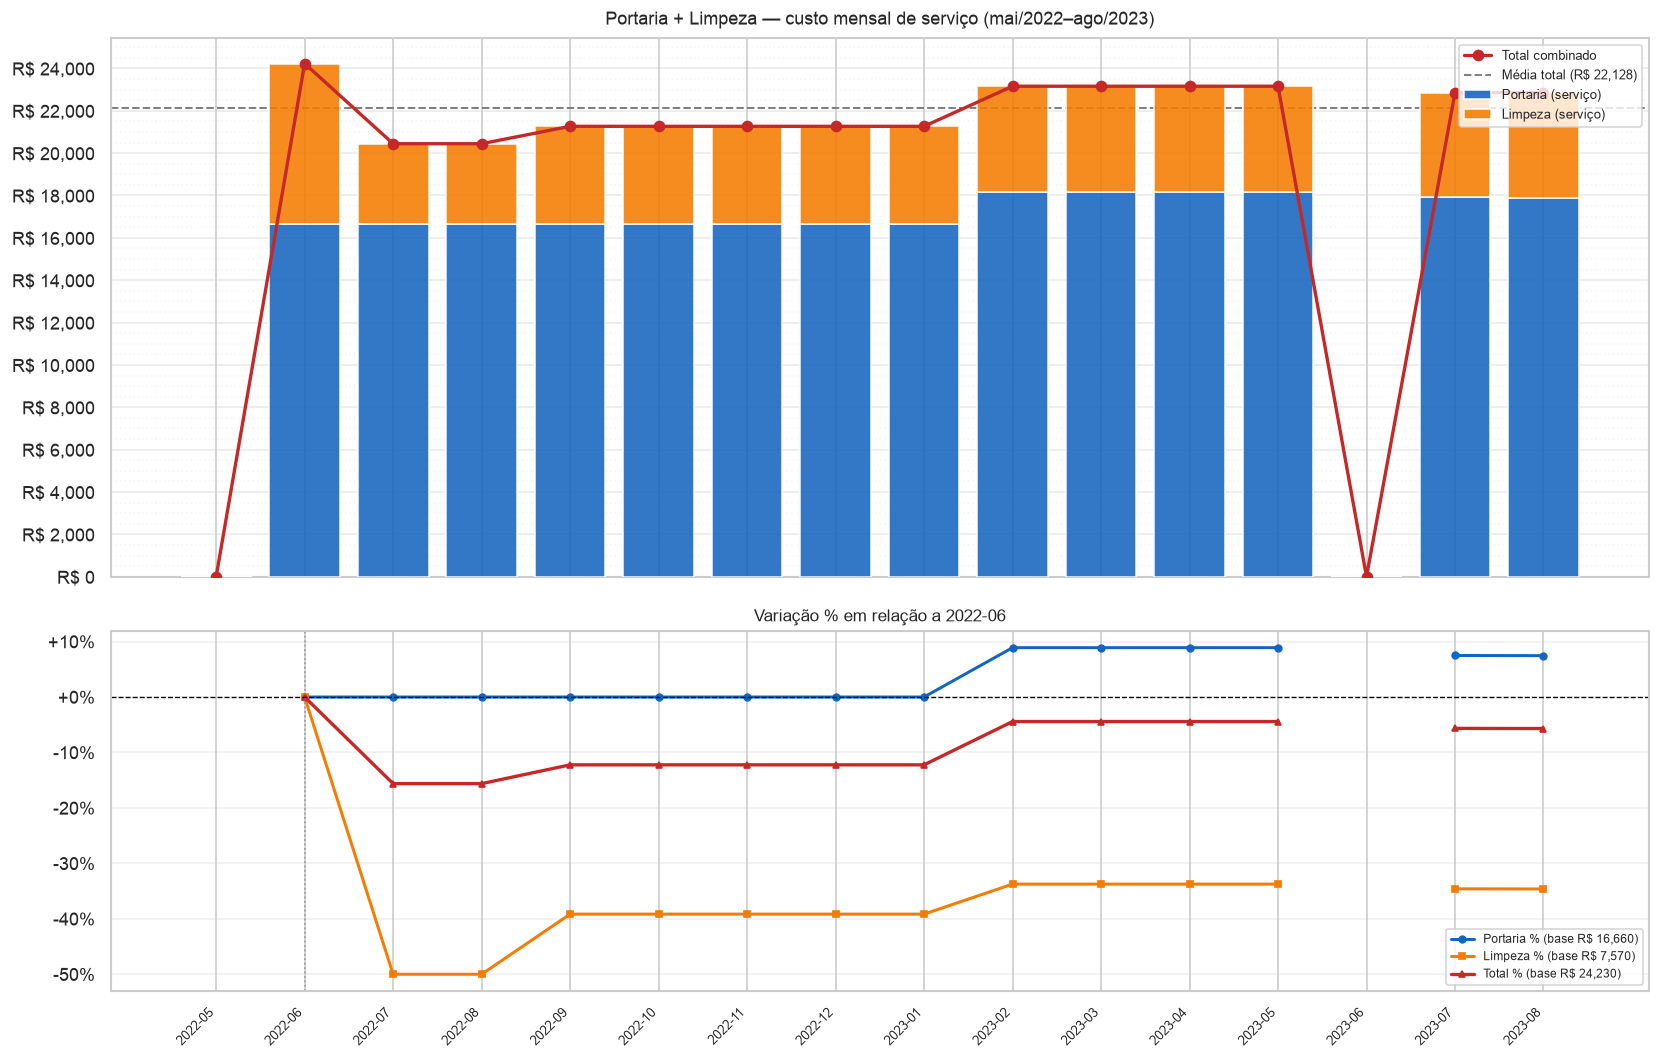


Portaria — total: R$ 241,661.88  |  média/mês: R$ 17,261.56
Limpeza  — total: R$ 68,134.39  |  média/mês: R$ 4,866.74
Total    — total: R$ 309,796.27  |  média/mês: R$ 22,128.31


In [239]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.6 Portaria + Limpeza/Zelador — evolução mensal (2022–2023)
# Somente custo de serviço (PG.SERV.PORTARIA e PG.SERV.LIMP.)
# ═══════════════════════════════════════════════════════════════════════════
port_df = df_prest[
    df_prest["evento"].str.upper().str.contains(r"PORTARIA|MISS[AÃ]O\s*D[EI]?\s*PAZ", regex=True, na=False)
    & (df_prest["tipo"] == "despesa")
].copy()

limp_df = df_prest[
    df_prest["evento"].str.upper().str.contains(r"SERV\.?\s*LIMP|LIMPEZA|ZELADOR", regex=True, na=False)
    & ~df_prest["evento"].str.upper().str.contains(r"MAT\.?\s*LIMP", regex=True, na=False)
    & (df_prest["tipo"] == "despesa")
].copy()

print("=== Portaria (serviço) ===")
print(port_df[["mes_ano", "evento", "valor"]].to_string(index=False))
print("\n=== Limpeza (serviço) ===")
print(limp_df[["mes_ano", "evento", "valor"]].to_string(index=False))

# Séries mensais
port_m  = port_df.groupby("mes_ano")["valor"].sum().reindex(todos_meses).fillna(0)
limp_m  = limp_df.groupby("mes_ano")["valor"].sum().reindex(todos_meses).fillna(0)
total_m = port_m + limp_m

# Base para % = primeiro mês com ambos os serviços
meses_completos = [m for m in todos_meses if port_m[m] > 0 and limp_m[m] > 0]
base_mes   = meses_completos[0] if meses_completos else todos_meses[0]
base_port  = float(port_m[base_mes])
base_limp  = float(limp_m[base_mes])
base_total = float(total_m[base_mes])
ref_total  = float(total_m[total_m > 0].mean())

print(f"\nBase: {base_mes}  "
      f"(portaria R$ {base_port:,.2f}, limpeza R$ {base_limp:,.2f})")

# ── Gráfico duplo ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={"height_ratios": [3, 2]})
x = range(len(todos_meses))

# Painel superior: barras empilhadas portaria + limpeza
ax1.bar(x, port_m, color="#1565c0", alpha=0.88, label="Portaria (serviço)", zorder=3)
ax1.bar(x, limp_m, bottom=port_m,  color="#f57c00", alpha=0.88,
        label="Limpeza (serviço)", zorder=3)
ax1.plot(x, total_m, color="#c62828", marker="o", linewidth=2.0, zorder=4,
         label="Total combinado")
ax1.axhline(ref_total, color="gray", linestyle="--", linewidth=1.2,
            label=f"Média total (R$ {ref_total:,.0f})")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax1.yaxis.set_major_locator(mticker.MultipleLocator(2000))
ax1.yaxis.set_minor_locator(mticker.MultipleLocator(500))
ax1.legend(fontsize=8, loc="upper right")
ax1.set_title("Portaria + Limpeza — custo mensal de serviço (mai/2022–ago/2023)",
              fontsize=11, pad=8)
ax1.grid(axis="y", which="major", alpha=0.4, zorder=0)
ax1.grid(axis="y", which="minor", alpha=0.15, linestyle=":", zorder=0)

# Painel inferior: variação % vs mês base
def pct_vs_base(s, base_val):
    if base_val <= 0:
        return pd.Series([float("nan")] * len(s), index=s.index)
    return ((s - base_val) / base_val * 100).where(s > 0)

ax2.plot(x, pct_vs_base(port_m,  base_port),  color="#1565c0", marker="o",
         markersize=4, linewidth=1.8, label=f"Portaria % (base R$ {base_port:,.0f})")
ax2.plot(x, pct_vs_base(limp_m,  base_limp),  color="#f57c00", marker="s",
         markersize=4, linewidth=1.8, label=f"Limpeza % (base R$ {base_limp:,.0f})")
ax2.plot(x, pct_vs_base(total_m, base_total), color="#c62828", marker="^",
         markersize=4, linewidth=2.0, label=f"Total % (base R$ {base_total:,.0f})")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axvline(todos_meses.index(base_mes), color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax2.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax2.legend(fontsize=7, loc="lower right")
ax2.set_title(f"Variação % em relação a {base_mes}", fontsize=10, pad=6)
ax2.grid(axis="y", alpha=0.3)

ax2.set_xticks(list(x))
ax2.set_xticklabels(todos_meses, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nPortaria — total: R$ {port_m.sum():,.2f}  |  média/mês: R$ {port_m[port_m>0].mean():,.2f}")
print(f"Limpeza  — total: R$ {limp_m.sum():,.2f}  |  média/mês: R$ {limp_m[limp_m>0].mean():,.2f}")
print(f"Total    — total: R$ {total_m.sum():,.2f}  |  média/mês: R$ {ref_total:,.2f}")

## 6. Exportar dados normalizados e anomalias

In [240]:
df_prest.to_csv(CSV_DIR / "prestacoes.csv", index=False)
print(f"✓ prestacoes.csv — {len(df_prest):,} registros (macro_categoria incluída)")

print("\n=== Arquivos em exports/csv/ ===")
for f in sorted(CSV_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:6.1f} KB")

✓ prestacoes.csv — 711 registros (macro_categoria incluída)

=== Arquivos em exports/csv/ ===
  anomalias.csv                              42.2 KB
  extratos.csv                              578.0 KB
  lancamentos_normalizados.csv              652.3 KB
  prestacoes.csv                             36.5 KB
